### Attribution

This notebook implements the **Expected Threat (xT)** model introduced by Karun Singh in
["Introducing Expected Threat (xT)"](https://karun.in/blog/expected-threat.html).
The transition-matrix and value-iteration code closely follows the
[socceraction](https://github.com/ML-KULeuven/socceraction) library's
[`xthreat` module](https://github.com/ML-KULeuven/socceraction/blob/master/socceraction/xthreat.py),
which is released under the
[MIT License](https://github.com/ML-KULeuven/socceraction/blob/master/LICENSE),
Copyright (c) Tom Decroos and contributors.

### Import Dependencies

In [1]:
import os
import json
from glob import glob
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))
from football_metrics.visualization_helper.kick_style import *
apply_kick_style()

### Helper Functions

In [2]:
def plot_pitch_grid(data, title, label, subtitle=None, fmt=".2f", cmap="magma", annot_size=10):
    """House grid heatmap for the xT pipeline — a pitch-style graph: the grid rectangle keeps the true pitch
    aspect (105 long x 68 wide), the magma ramp shows the value, and the colourbar sits UNDERNEATH like
    every house pitch chart. Cells are annotated when the grid is small enough to stay readable."""
    data = np.asarray(data, dtype=float)
    w, l = data.shape
    m = KICK_MARGIN_IN
    Wf = 14.0
    grid_w = Wf - 2 * m
    grid_h = grid_w * 68.0 / 105.0                      # outer rectangle = pitch 105 x 68
    title_h = (20 + 10 + 18) if subtitle else 20        # kick_title centres this block above the grid
    header_band = title_h / 72.0 + 2 * m                # title (+ subtitle) + margins above the grid
    cbar_band = 2 * m + 0.74                            # bottom band for the horizontal colourbar (house)
    Hf = header_band + grid_h + cbar_band
    fig = plt.figure(figsize=(Wf, Hf), facecolor=KICK["figure"])
    ax = fig.add_axes([m / Wf, cbar_band / Hf, grid_w / Wf, grid_h / Hf]); ax.set_facecolor(KICK["figure"])
    from matplotlib.colors import PowerNorm
    norm = PowerNorm(gamma=0.45, vmin=0, vmax=(np.nanmax(data) or 1.0))   # spread the skewed low-mid values
    im = ax.imshow(data, cmap=cmap, origin="lower", extent=[0, l, 0, w], aspect="auto", norm=norm)
    ax.set_xlim(0, l); ax.set_ylim(0, w)
    ax.set_xticks(np.arange(0, l + 1), minor=True); ax.set_yticks(np.arange(0, w + 1), minor=True)
    ax.grid(which="minor", color=KICK["figure"], linewidth=1.4); ax.tick_params(which="minor", length=0)
    ax.set_xticks([]); ax.set_yticks([])
    if w * l <= 260:
        for i in range(w):
            for j in range(l):
                v = data[i, j]
                txt = f"{int(round(v))}" if fmt == "d" else format(v, fmt)
                ax.text(j + 0.5, i + 0.5, txt, ha="center", va="center", fontsize=annot_size,
                        color=KICK["figure"] if norm(v) > 0.55 else W(0.82))
    ax._kick_bounds = (0, l, 0, w); ax._kick_cbar_pos = "bottom"
    kick_cbar(fig, ax, im, label)
    kick_title(fig, ax, title, subtitle, pitch=True)
    plt.show()

### Data Preprocessing

An xT model is fundamentally concerned with actions that actively change the ball’s location or directly attempt to convert threat into a shot.

The four event types retained here — **Pass**, **Carry**, **Dribble**, and **Shot** — are precisely the actions that drive this process. 

For this reason, we also restrict the analysis to sequences whose StatsBomb `play_pattern` is **Regular Play**, since including set-piece situations such as corners would artificially inflate threat values in fixed regions of the pitch that reflect restart structure rather than open-play ball progression. Note that this filter is stricter than "all open play": phases tagged *From Counter*, *From Throw In*, *From Goal Kick*, or *From Keeper* are also excluded, which biases the surface slightly toward settled-possession play.

In [3]:
XT_EVENT_TYPES = {
    "Pass",
    "Carry",
    "Dribble",
    "Shot",
}

def load_events(f):
    with open(f, "r") as fp:
        raw = json.load(fp)

    df = pd.json_normalize(raw, sep="_", max_level=2)
    df["match_id"] = os.path.basename(f).replace(".json", "")

    df = df[
        (df["play_pattern_name"] == "Regular Play") &
        (df["type_name"].isin(XT_EVENT_TYPES))
    ]

    return df

We use multiprocessing to speed up the ingestion of JSON files into a unified DataFrame.

In [4]:
# sorted(): glob returns filesystem order, so an unsorted sweep silently reshuffles the event frame
event_files = sorted(glob("/path/to/your/statsbomb/data/events/*.json"))
test_files = event_files[:2000]  # We only check the first 2000 matches

print(f"Loading {len(test_files)} matches...")
with Pool(cpu_count()) as pool:
    filtered_list = list(pool.imap(load_events, test_files))

filtered_events = pd.concat(filtered_list, ignore_index=True)

Loading 2000 matches...


### Feature Engineering

The Expected Threat (xT) model is built on the idea of **transitions**. In the StatsBomb dataset, a `Pass` has a *pass_end_location*. A `Carry` has a *carry_end_location*. However, a `Dribble` (taking on an opponent) **only records where the event occurred**. Therefore, we look ahead to the starting position of the same player's next retained event to determine where the ball moved — but only when that event occurs in the **same period and possession**. Otherwise (the ball was lost or play was interrupted) the end location is left missing and the dribble is dropped from the transition data.

$$
\text{End Location}_{\text{Dribble}_{i}} = \text{Start Location}_{\text{Event}_{i+1}} \quad \text{(same player, period, and possession)}
$$

In [5]:
filtered_events = filtered_events.sort_values(
    ["match_id", "player_id", "index"]
)

grouped = filtered_events.groupby(["match_id", "player_id"])
next_loc = grouped["location"].shift(-1)

# Only trust the look-ahead when the player's next retained event happens in
# the same period and possession; otherwise the ball was lost or play was
# interrupted, so the imputed end location is left missing (dropped later).
same_phase = (
    (grouped["period"].shift(-1) == filtered_events["period"])
    & (grouped["possession"].shift(-1) == filtered_events["possession"])
)
next_loc = next_loc.where(same_phase)

filtered_events = filtered_events.assign(
    next_start_x = next_loc.str[0],
    next_start_y = next_loc.str[1],
)

In [6]:
def build_action_df(df, action_type, start_col, end_col, result_func, is_list_end=True):
    """
    Generic builder for Pass, Carry, Shot, and Dribble action frames.
    """
    tmp = df[df["type_name"] == action_type].copy()

    # start location always list
    tmp["start_x"] = tmp[start_col].str[0]
    tmp["start_y"] = tmp[start_col].str[1]

    # end location: list or scalar
    if is_list_end:
        tmp["end_x"] = tmp[end_col].str[0]
        tmp["end_y"] = tmp[end_col].str[1]
    else:
        # end_col is name prefix like "next_start"
        tmp["end_x"] = tmp[end_col + "_x"]
        tmp["end_y"] = tmp[end_col + "_y"]

    # compute success: 0/1
    tmp["result"] = tmp.apply(result_func, axis=1)

    tmp["type_name"] = action_type

    return tmp[[
        "match_id", "team_id", "player_id", "index", "period",
        "start_x", "start_y", "end_x", "end_y",
        "result", "type_name"
    ]]

In [7]:
df_shot = build_action_df(
    filtered_events,
    action_type="Shot",
    start_col="location",
    end_col="shot_end_location",
    result_func=lambda r: 1 if r["shot_outcome_name"] == "Goal" else 0
)

df_pass = build_action_df(
    filtered_events,
    action_type="Pass",
    start_col="location",
    end_col="pass_end_location",
    result_func=lambda r: 1 if pd.isna(r["pass_outcome_name"]) else 0
)

df_carry = build_action_df(
    filtered_events,
    action_type="Carry",
    start_col="location",
    end_col="carry_end_location",
    result_func=lambda r: 1
)

df_dribble = build_action_df(
    filtered_events,
    action_type="Dribble",
    start_col="location",
    end_col="next_start",           
    result_func=lambda r: 1 if r["dribble_outcome_name"] == "Complete" else 0,
    is_list_end=False             
)

In [8]:
df_actions = pd.concat([df_pass, df_carry, df_dribble, df_shot], ignore_index=True)
df_actions = df_actions.dropna(subset=["end_x", "end_y"]).reset_index(drop=True)

type_map = {
    "Pass": 0,
    "Carry": 1,
    "Dribble": 2,
    "Shot": 3,
}
df_actions["type_id"] = df_actions["type_name"].map(type_map)
df_actions["result_id"] = df_actions["result"]

### Discretizing the Pitch 

The pitch is a **continuous space** (120×80 units), but we need to represent it as a finite set of states for our **Markov model**. We divide the pitch into an $N×M$ grid. Each $(x,y)$ coordinate is mapped to a specific cell index, which we then flatten into a single state $s$.

In [9]:
# Grid & Pitch Constants
M = 12   # rows (y)
N = 16   # cols (x)

PITCH_LENGTH = 120.0  # StatsBomb x
PITCH_WIDTH = 80.0    # StatsBomb y

In [10]:
def get_cell_indexes(
    x: pd.Series,
    y: pd.Series,
    l: int = N,
    w: int = M,
):
    xi = (x / PITCH_LENGTH * l).astype("int64").clip(0, l - 1)
    yj = (y / PITCH_WIDTH * w).astype("int64").clip(0, w - 1)
    return xi, yj


def get_flat_indexes(
    x: pd.Series,
    y: pd.Series,
    l: int = N,
    w: int = M,
) -> pd.Series:
    xi, yj = get_cell_indexes(x, y, l, w)
    return yj * l + xi

The following `count` function performs three essential operations:
- **Filtering**: It ignores events with missing coordinates (NaN) to prevent calculation errors.
- **Discretization**: It uses `get_flat_indexes` to translate every $(x,y)$ coordinate into a specific cell ID on our 12×16 grid.
- **Aggregation**: It tallies up every occurrence to create a "Population Map" of the pitch.

In [11]:
def count(
    x: pd.Series,
    y: pd.Series,
    l: int = N,
    w: int = M,
):
    """
    Count number of actions occurring in each cell of the grid.
    Returns a (w,l) matrix.
    """
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]

    flat_indexes = get_flat_indexes(x, y, l, w)
    vc = flat_indexes.value_counts(sort=False)

    vector = np.zeros(w * l, dtype=int)
    vector[vc.index] = vc
    return vector.reshape((w, l))

This heatmap down below visualizes the **spatial distribution** of all key actions (`Passes`, `Carries`, `Dribbles`, and `Shots`) within our discretized pitch. 

This serves as a critical data-quality check, ensuring we have sufficient event volume across the pitch to generate reliable Expected Threat values.

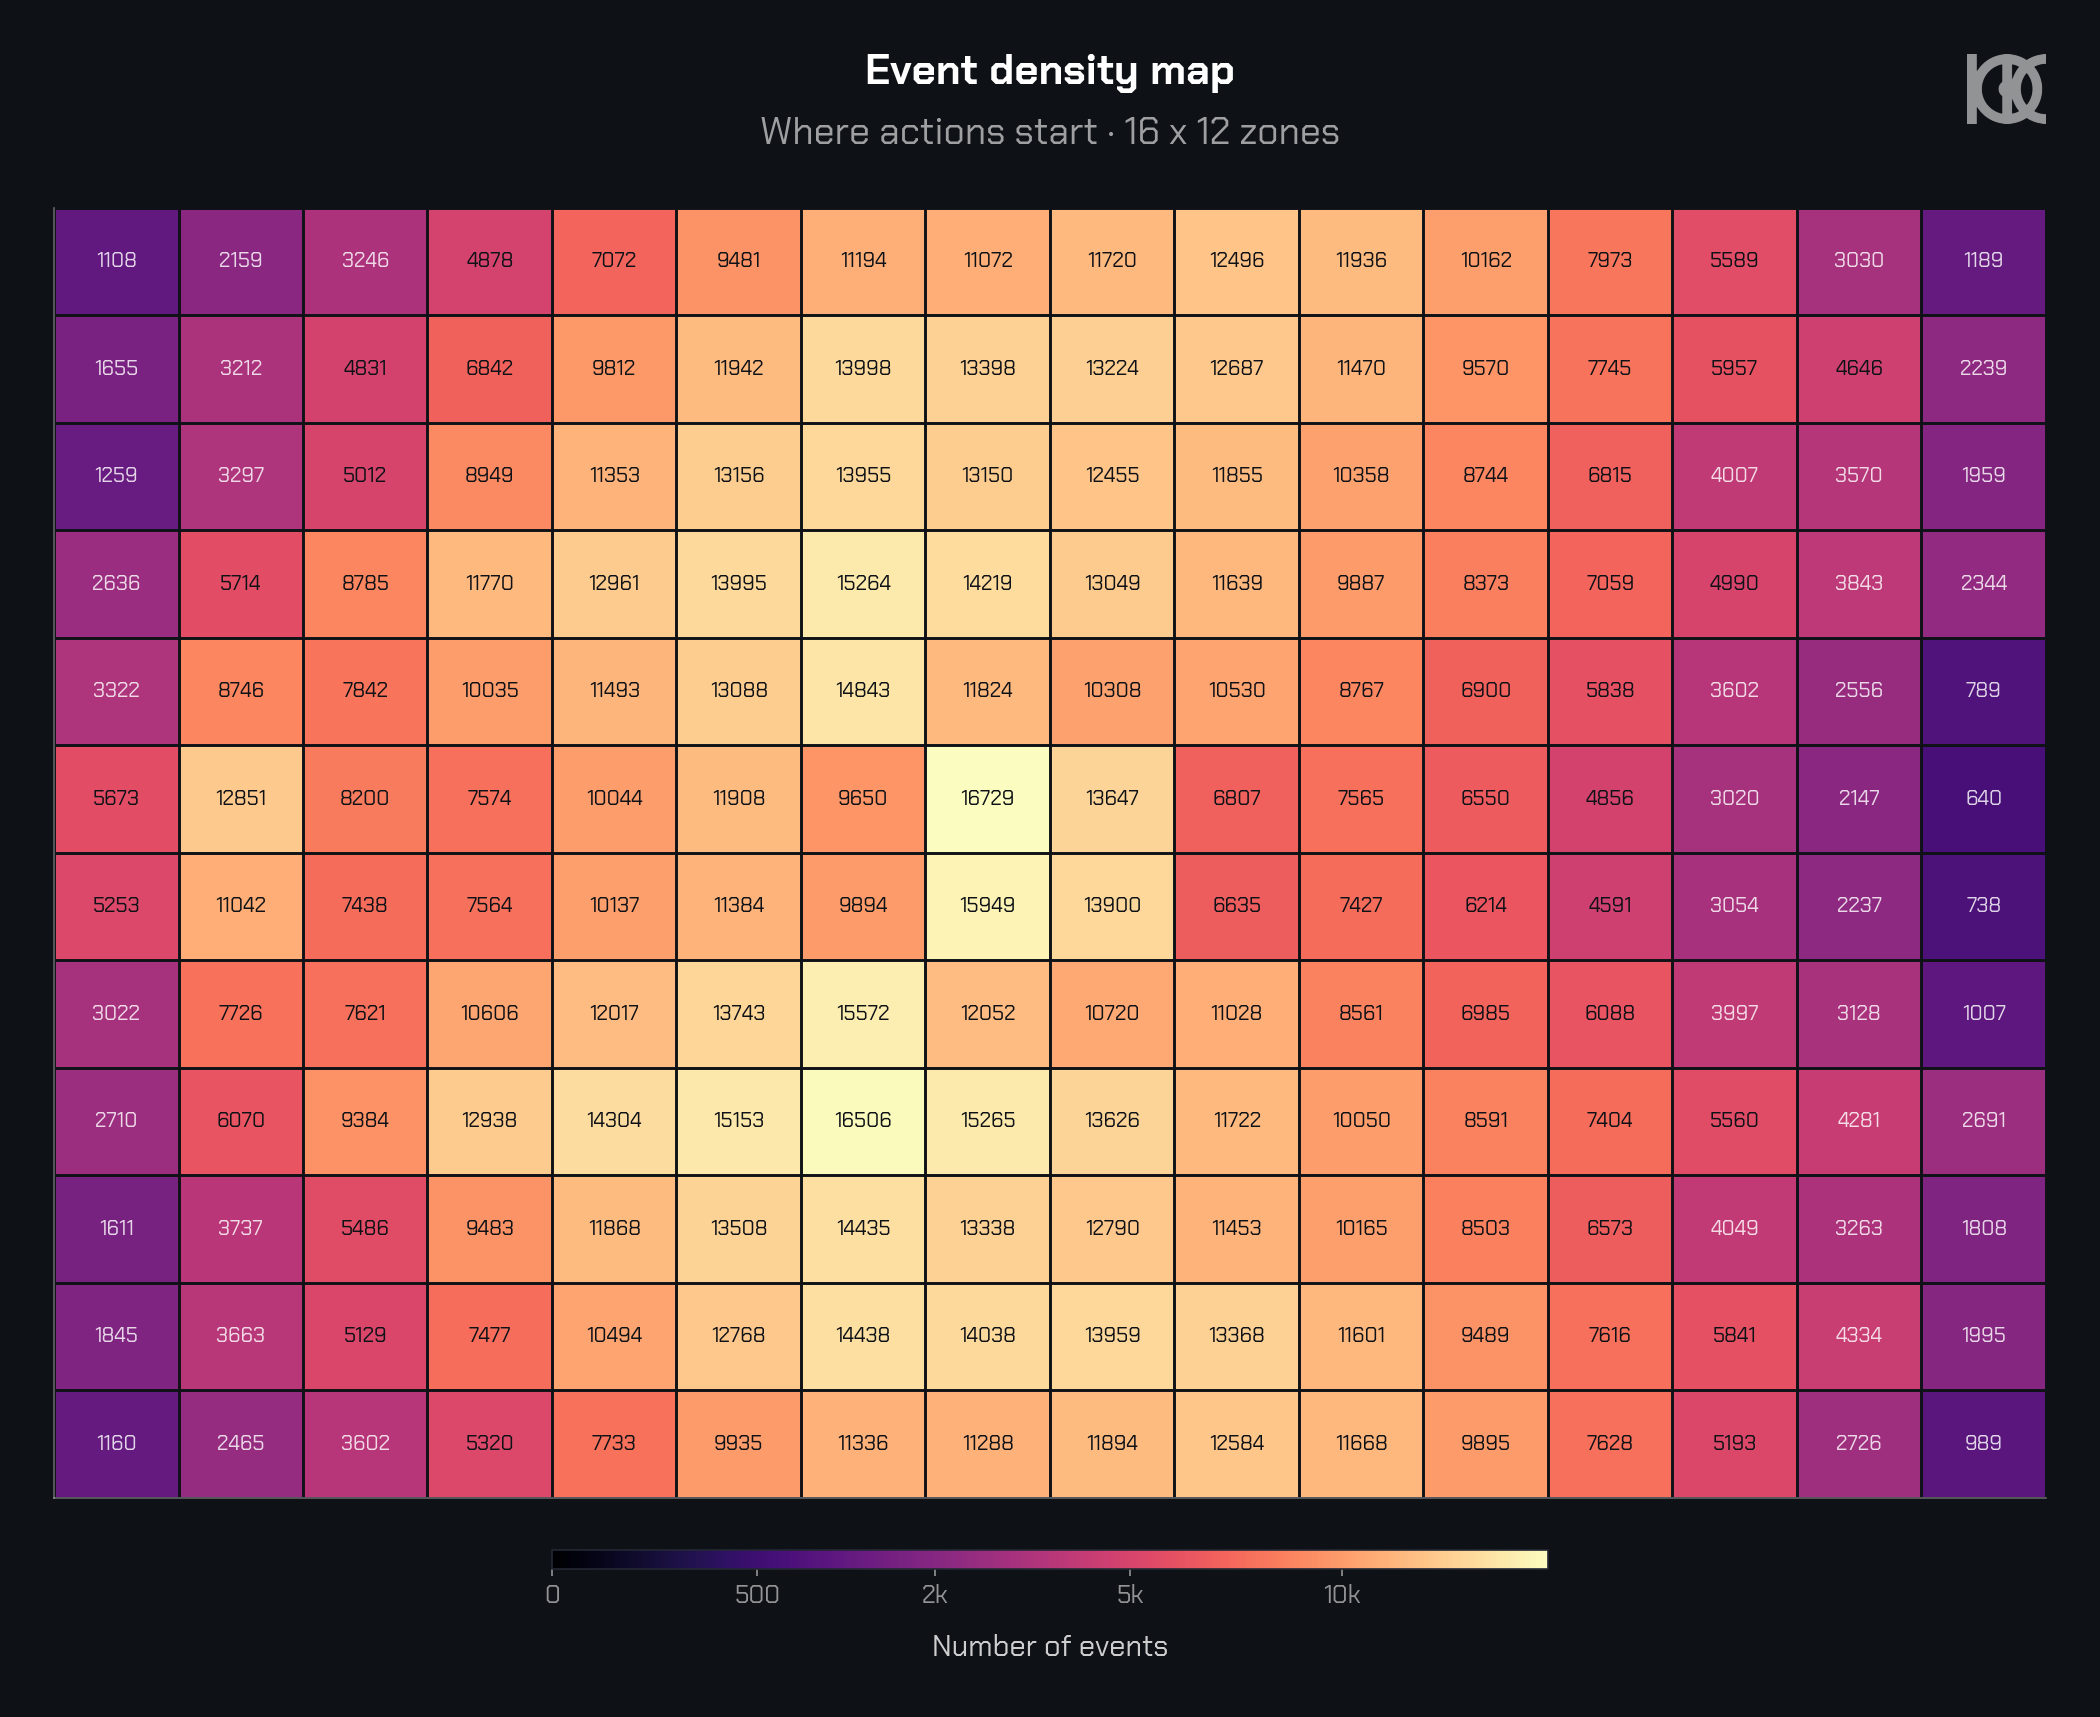

In [12]:
event_counts = count(df_actions["start_x"], df_actions["start_y"])

plot_pitch_grid(event_counts, "Event density map", "Number of events",
                subtitle="Where actions start · 16 x 12 zones", fmt="d")

### Calculating Immediate Reward

The core philosophy of the `Expected Threat` model is that the value of having the ball in a certain cell s is the sum of two distinct possibilities:
- The **Immediate Threat**: The probability of scoring right now by taking a shot.
- The **Future Threat**: The probability of moving the ball to a "better" cell and scoring from there in the future.

Mathematically, we solve for the value of each cell using this iterative Bellman equation:

$$
xT_s = \underbrace{(P(\text{Shot}|s) \times P(\text{Goal}|\text{Shot}, s))}_{\text{Immediate Reward}} + \underbrace{P(\text{Move}|s) \sum_{s' \in S} T(s \to s') xT_{s'}}_{\text{Expected Future Value}}
$$

Currently, we are focusing on the **Immediate Reward** $(g_s​)$. This is the portion of the equation that defines the "payoff" for being near the goal.

$$
g_s = P(\text{Shot}|s) \times P(\text{Goal}|\text{Shot}, s)
$$

To calculate this "*Goal Surface*," we are building the following two components:
- **Action Probabilities** $(P(Shot∣s))$: Determining if a player in cell $s$ is likely to shoot or move.
- **Scoring Probabilities** $(P(Goal∣Shot,s))$: Determining the historical success rate of shots from that specific cell.

In [13]:
SHOT_ID = 3           # type_id for Shot
MOVE_TYPE_IDS = {0,1,2}  # Pass, Carry, Dribble 

In [14]:
def safe_divide(a, b):
    """
    Element-wise divide, but return 0 where denominator is 0.
    """
    return np.divide(a, b, out=np.zeros_like(a, dtype="float64"), where=b != 0, casting="unsafe")

def get_scoring_prob(actions: pd.DataFrame, l: int = N, w: int = M):
    """
    Compute P(score | shoot from cell) as a (w,l) matrix.
    """
    shot_actions = actions[actions["type_id"] == SHOT_ID]
    goals = shot_actions[shot_actions["result_id"] == 1]

    shotmatrix = count(shot_actions["start_x"], shot_actions["start_y"], l, w)
    goalmatrix = count(goals["start_x"], goals["start_y"], l, w)

    return safe_divide(goalmatrix, shotmatrix)

In [15]:
def get_move_actions(actions: pd.DataFrame) -> pd.DataFrame:
    """
    All ball-progressing actions (pass, carry, dribble).
    """
    return actions[actions["type_id"].isin(MOVE_TYPE_IDS)]


def get_successful_move_actions(actions: pd.DataFrame) -> pd.DataFrame:
    """
    Successful ball-progressing actions only.
    """
    move_actions = get_move_actions(actions)
    return move_actions[move_actions["result_id"] == 1]


def get_action_prob(
    actions: pd.DataFrame,
    l: int = N,
    w: int = M,
):
    """
    For each cell, compute:
        P(shot | in cell), P(move | in cell)
    """
    move_actions = get_move_actions(actions)
    shot_actions = actions[actions["type_id"] == SHOT_ID]

    movematrix = count(move_actions["start_x"], move_actions["start_y"], l, w)
    shotmatrix = count(shot_actions["start_x"], shot_actions["start_y"], l, w)
    totalmatrix = movematrix + shotmatrix

    p_shot = safe_divide(shotmatrix, totalmatrix)
    p_move = safe_divide(movematrix, totalmatrix)
    return p_shot, p_move

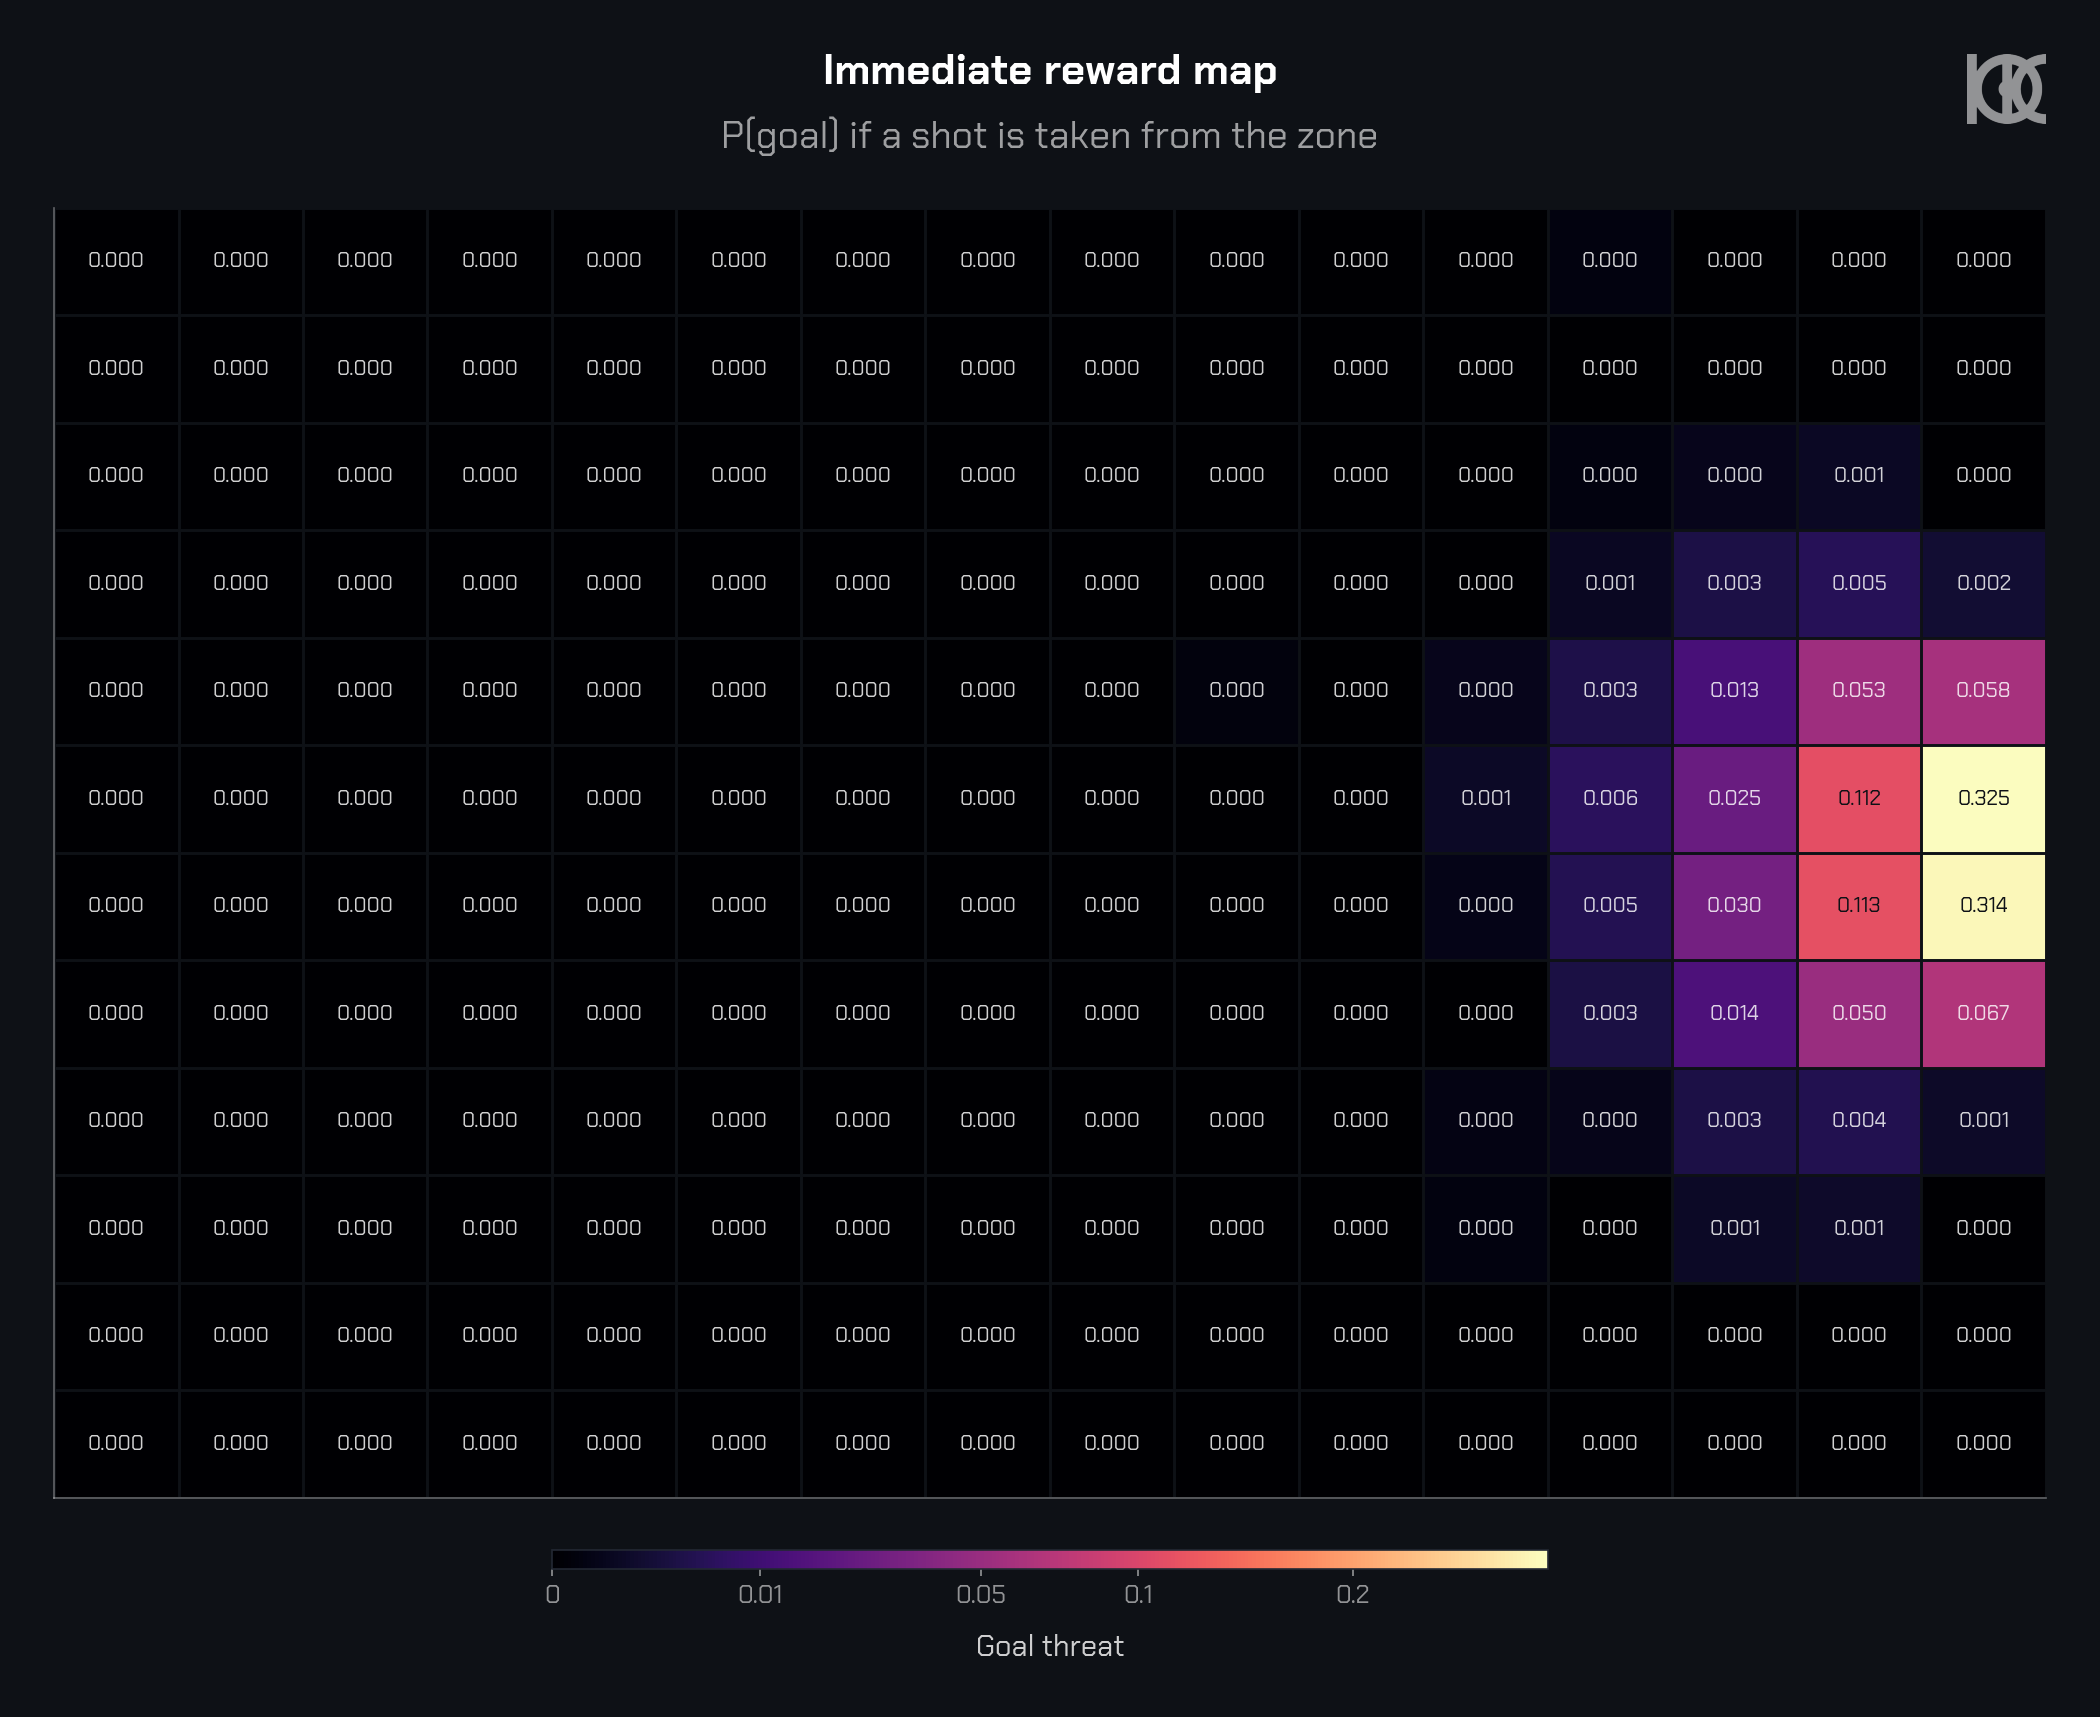

In [16]:
p_scoring = get_scoring_prob(df_actions)
p_shot, p_move = get_action_prob(df_actions)

immediate_threat = p_shot * p_scoring

plot_pitch_grid(immediate_threat, "Immediate reward map", "Goal threat",
                subtitle="P(goal) if a shot is taken from the zone", fmt=".3f")

### Calculating Expected Future Threat

While the first half of our equation dealt with immediate shots, the second half focuses on the potential of a possession. Most actions on a pitch are not shots; they are moves (passes, carries, dribbles) intended to transition the ball into a higher-value state.

The Future Threat of a cell $s$ is the probability that moving the ball will eventually lead to a goal.

We represent this mathematically as the probability of moving, multiplied by the weighted average of the xT values of all possible destination cells:

$$
P(\text{Move}|s) \sum_{s' \in S} T(s \to s') xT_{s}'
$$

Where
- $P(Move∣s)$: the Action Probability. It represents how likely a player is to choose a "moving" action (Pass, Carry, or Dribble) instead of shooting when they are in cell s.
- $T(s→s′)$: the Transition Probability. It represents the likelihood that a move attempted from cell $s$ is completed successfully into cell $s′$. Because we divide by **all attempted** moves from $s$ (not just the successful ones), each row sums to less than 1 — the missing mass is the probability of losing the ball, a built-in turnover penalty. It captures the typical "passing lanes" and movement patterns from that specific area of the pitch.
- $xT_{s}′$​: the Target Value. It is the Expected Threat value of the destination cell s′.
- $\sum_{s' \in S}$​: the Summation over all states. Because a move from cell $s$ could end up in any other cell on the pitch, we sum the transition-weighted values of every possible destination to get a single "Expected Future Value."

If we look closely at our final equation, we encounter a "chicken and egg" problem:

$$
xT_s = \underbrace{(P(\text{Shot}|s) \times P(\text{Goal}|\text{Shot}, s))}_{\text{Immediate Reward}} + \underbrace{P(\text{Move}|s) \sum_{s' \in S} T(s \to s') xT_{s'}}_{\text{Expected Future Value}}
$$

We want to find $xT_s$​, but the right side of the equation contains $xT_s′$​. Since the ball can move anywhere, every cell's value depends on every other cell's value. We have a system of 192 equations (for our 16×12 grid) that are all interconnected.

To solve this "chicken and egg" problem, we use an intuitive concept called **Backward Bleeding** (mathematically known as **Value Iteration**).

Imagine the pitch is completely dark, except for the area directly in front of the goal, which is glowing with a bright light. That light represents our **Immediate Reward** — the actual goals. (As demonstrated by the graph above)
- **Iteration 0**: Only the six-yard box is "lit up." The rest of the pitch has zero value because you can rarely score a goal directly from the halfway line.
- **Iteration 1**: We ask: "Which cells can pass the ball into that lit-up area?" Cells in the "Zone 14" or the wings that have a high Transition Probability $(T)$ into the box now catch some of that "light." They start to glow.
- **Iteration 2**: Now we ask: "Which cells can pass into the cells that just started glowing?" The light (threat) starts to bleed backward from the goal, through the midfield, and eventually toward the defenders and even the goalkeeper.

The threat "bleeds" backward because a pass is only as valuable as the place it ends up. By repeating this process over and over, the values across the entire pitch eventually stabilize. A cell at the halfway line finally gets a value not because you can score from there, but because it is three successful passes away from someone who can.

In [17]:
def move_transition_matrix(
    actions: pd.DataFrame,
    l: int = N,
    w: int = M,
):
    """
    For move actions, compute transition probabilities between cells:
        T[i,j] = P(move succeeds and ends in cell j | move attempted from cell i)
    Successful end-cell counts are divided by ALL attempted moves from i, so
    each row sums to <= 1; the missing mass is the turnover probability.
    """
    move_actions = get_move_actions(actions)

    X = pd.DataFrame()
    X["start_cell"] = get_flat_indexes(move_actions["start_x"], move_actions["start_y"], l, w)
    X["end_cell"] = get_flat_indexes(move_actions["end_x"], move_actions["end_y"], l, w)
    X["result_id"] = move_actions["result_id"]

    vc = X["start_cell"].value_counts(sort=False)
    start_counts = np.zeros(w * l)
    start_counts[vc.index] = vc

    transition_matrix = np.zeros((w * l, w * l), dtype=float)

    for i in range(w * l):
        # Successful moves that start in cell i
        vc2 = X[(X["start_cell"] == i) & (X["result_id"] == 1)]["end_cell"].value_counts(sort=False)
        if start_counts[i] > 0:
            transition_matrix[i, vc2.index] = vc2 / start_counts[i]
        # else row stays zeros: no data for moves from this cell

    return transition_matrix

The **Transition Matrix** is the mathematical "engine" of the xT model. If we think of the pitch as a network of 192 different "stations" (our grid cells), the transition matrix is the timetable that tells us the probability of traveling from one station to any other.

In [18]:
trans_matrix = move_transition_matrix(df_actions)
print(f"Transition Matrix Shape: {trans_matrix.shape}") 

Transition Matrix Shape: (192, 192)


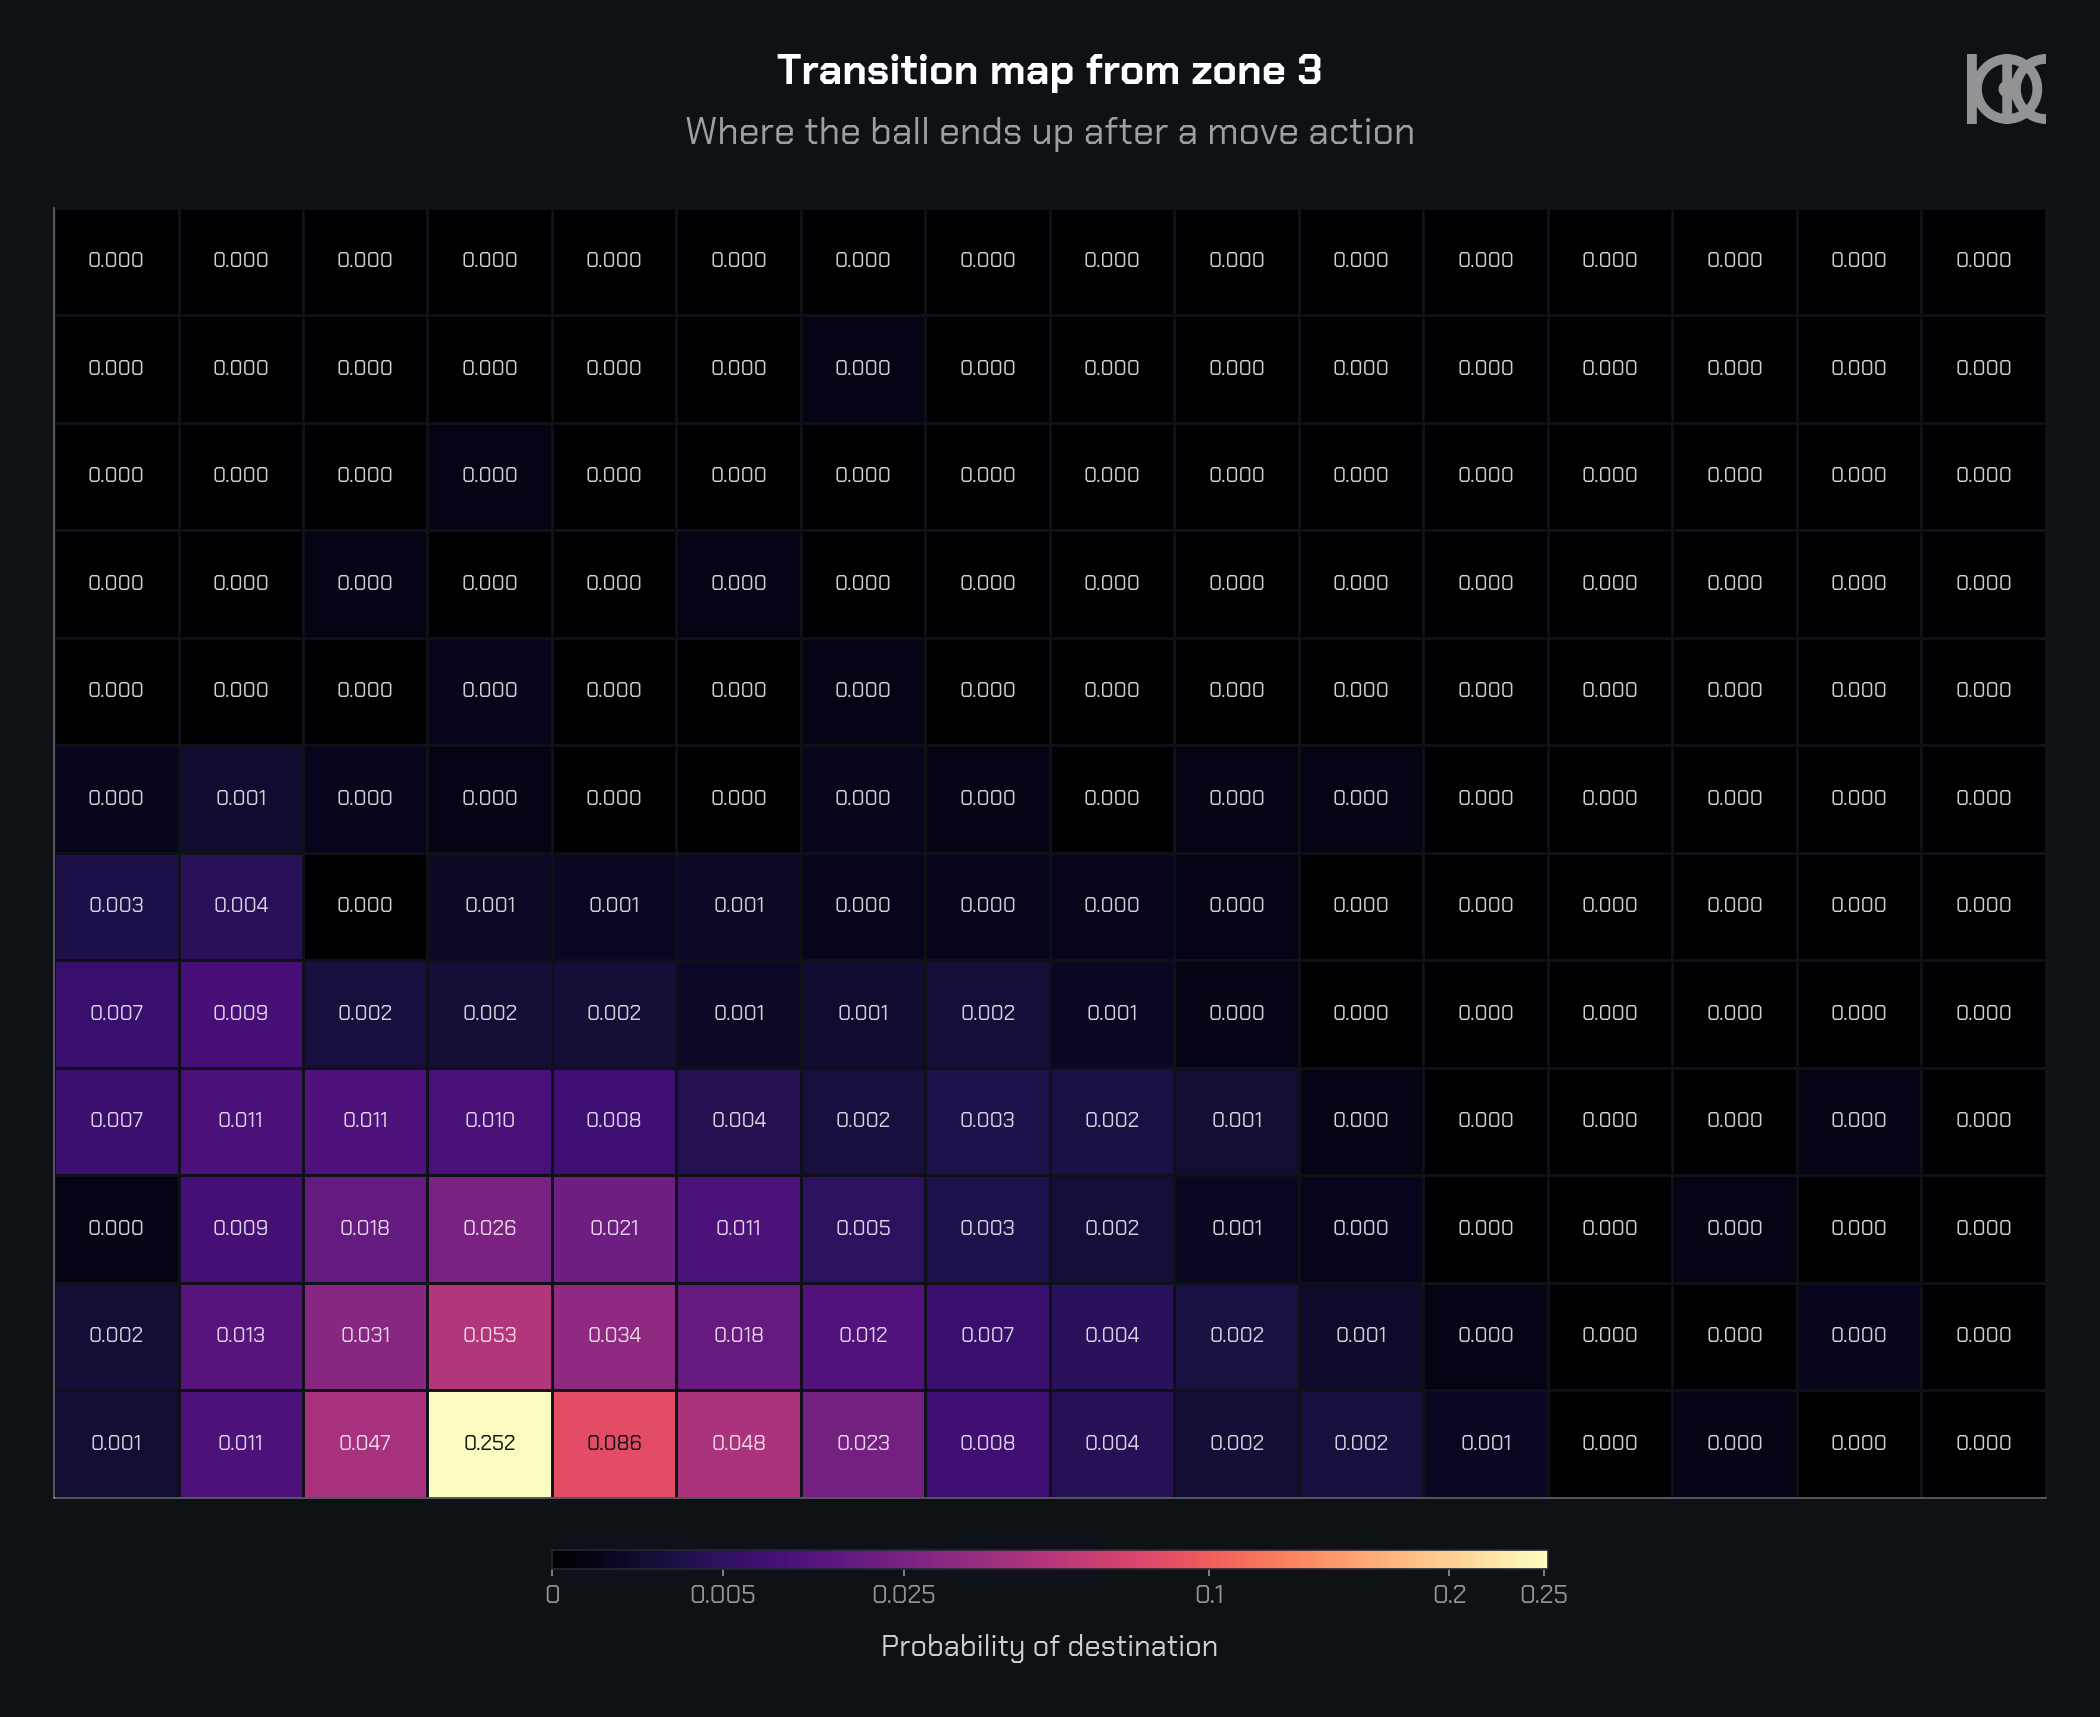

In [19]:
start_cell_idx = 3  # Change to the cell you want to observe

move_map = trans_matrix[start_cell_idx].reshape(M, N)

plot_pitch_grid(
    move_map,
    title=f"Transition map from zone {start_cell_idx}",
    subtitle="Where the ball ends up after a move action",
    label="Probability of destination",
    fmt=".3f",
)

In [20]:
# Initialize xT grid with zeros
xt = np.zeros((M, N))
eps = 1e-5
max_iters = 100
diff = 1.0
iterations = 0

# Immediate reward (Goal Surface)
gs = p_scoring * p_shot

while diff > eps and iterations < max_iters:
    total_payoff = np.zeros((M, N))
    
    # Flatten xt for matrix multiplication with transition matrix
    xt_flat = xt.flatten()
    
    for y in range(M):
        for x in range(N):
            s = y * N + x
            # Dot product of transition row for cell s and current xT values
            future_val = np.dot(trans_matrix[s], xt_flat)
            total_payoff[y, x] = future_val

    new_xt = gs + (p_move * total_payoff)
    diff = np.max(np.abs(new_xt - xt))
    xt = new_xt
    iterations += 1

if diff > eps:
    print(f"Warning: xT did not converge after {max_iters} iterations (residual {diff:.2e}).")
else:
    print(f"xT calculation converged after {iterations} iterations.")

# Persist the trained xT value surface for reuse (see model_utils/)
np.save("model_utils/xt_surface.npy", xt)
print(f"Saved xT surface {xt.shape} -> model_utils/xt_surface.npy")

xT calculation converged after 47 iterations.
Saved xT surface (12, 16) -> model_utils/xt_surface.npy


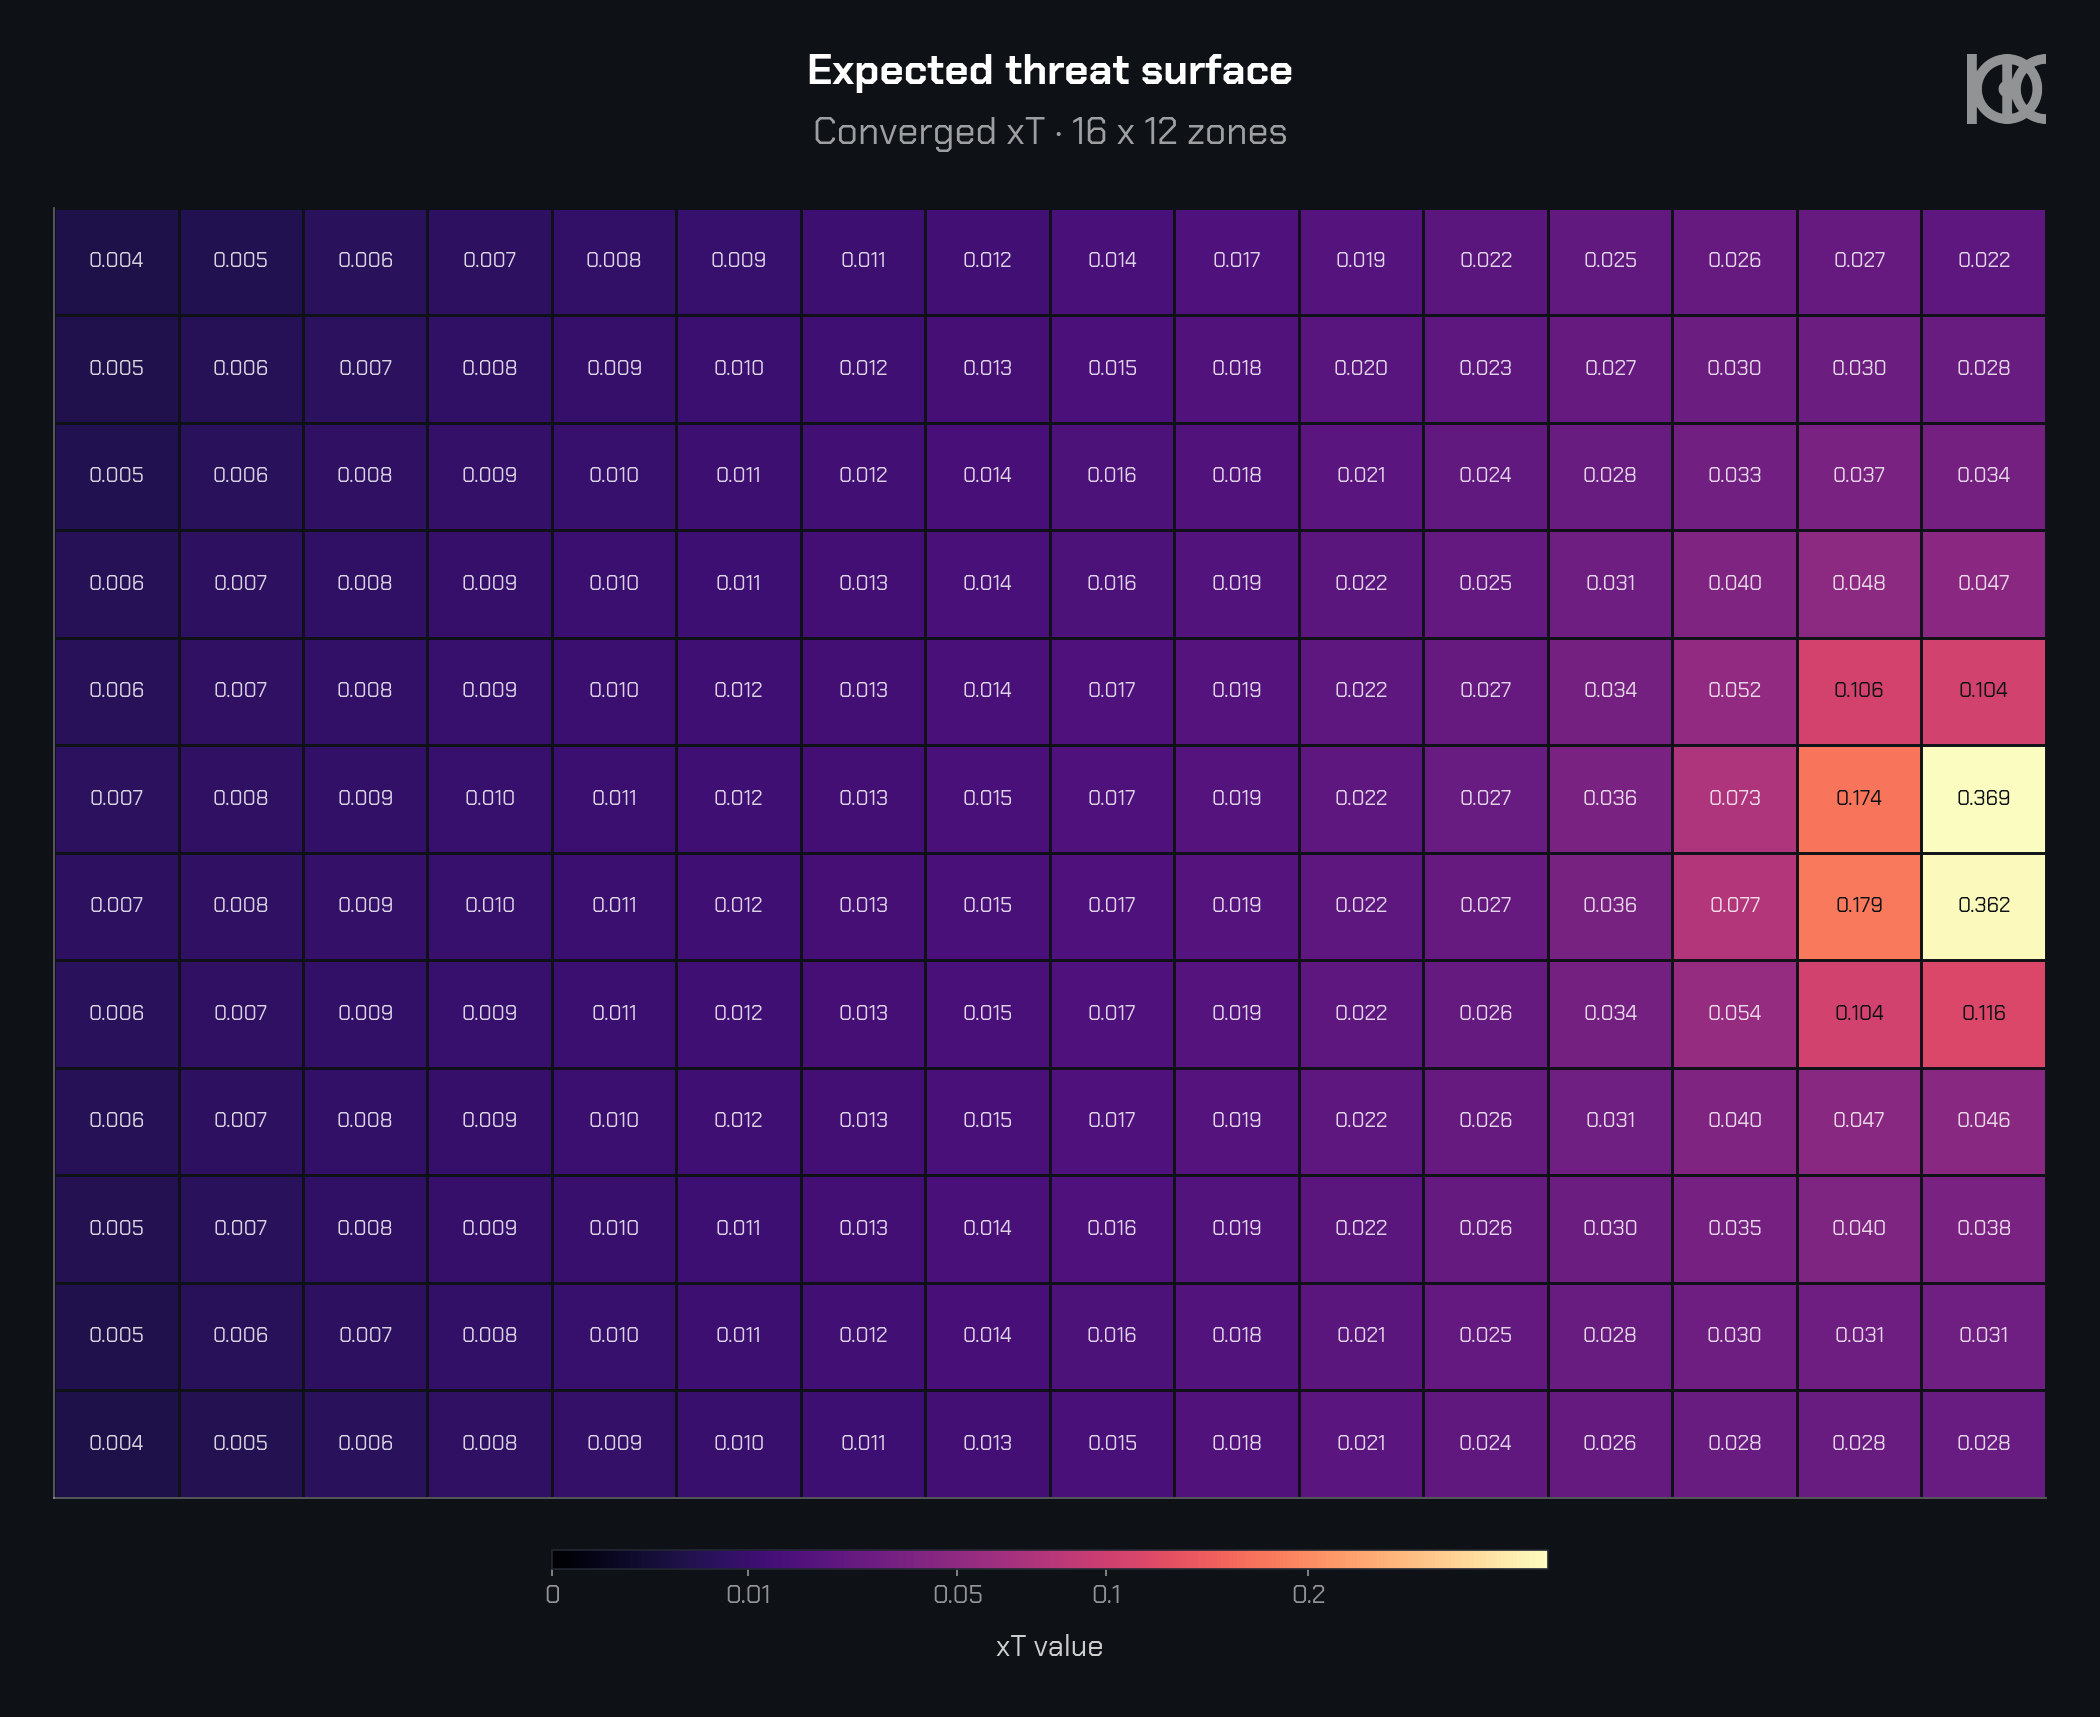

In [21]:
# Display final xT grid using the helper function
plot_pitch_grid(
    data=xt,
    title="Expected threat surface",
    subtitle="Converged xT · 16 x 12 zones",
    label="xT value",
    fmt=".3f",
)

### BONUS 1: Higher Resolution xT Grid Setup

New Grid Resolution: 32x24 (768 states)
Fine-grid xT converged after 47 iterations.


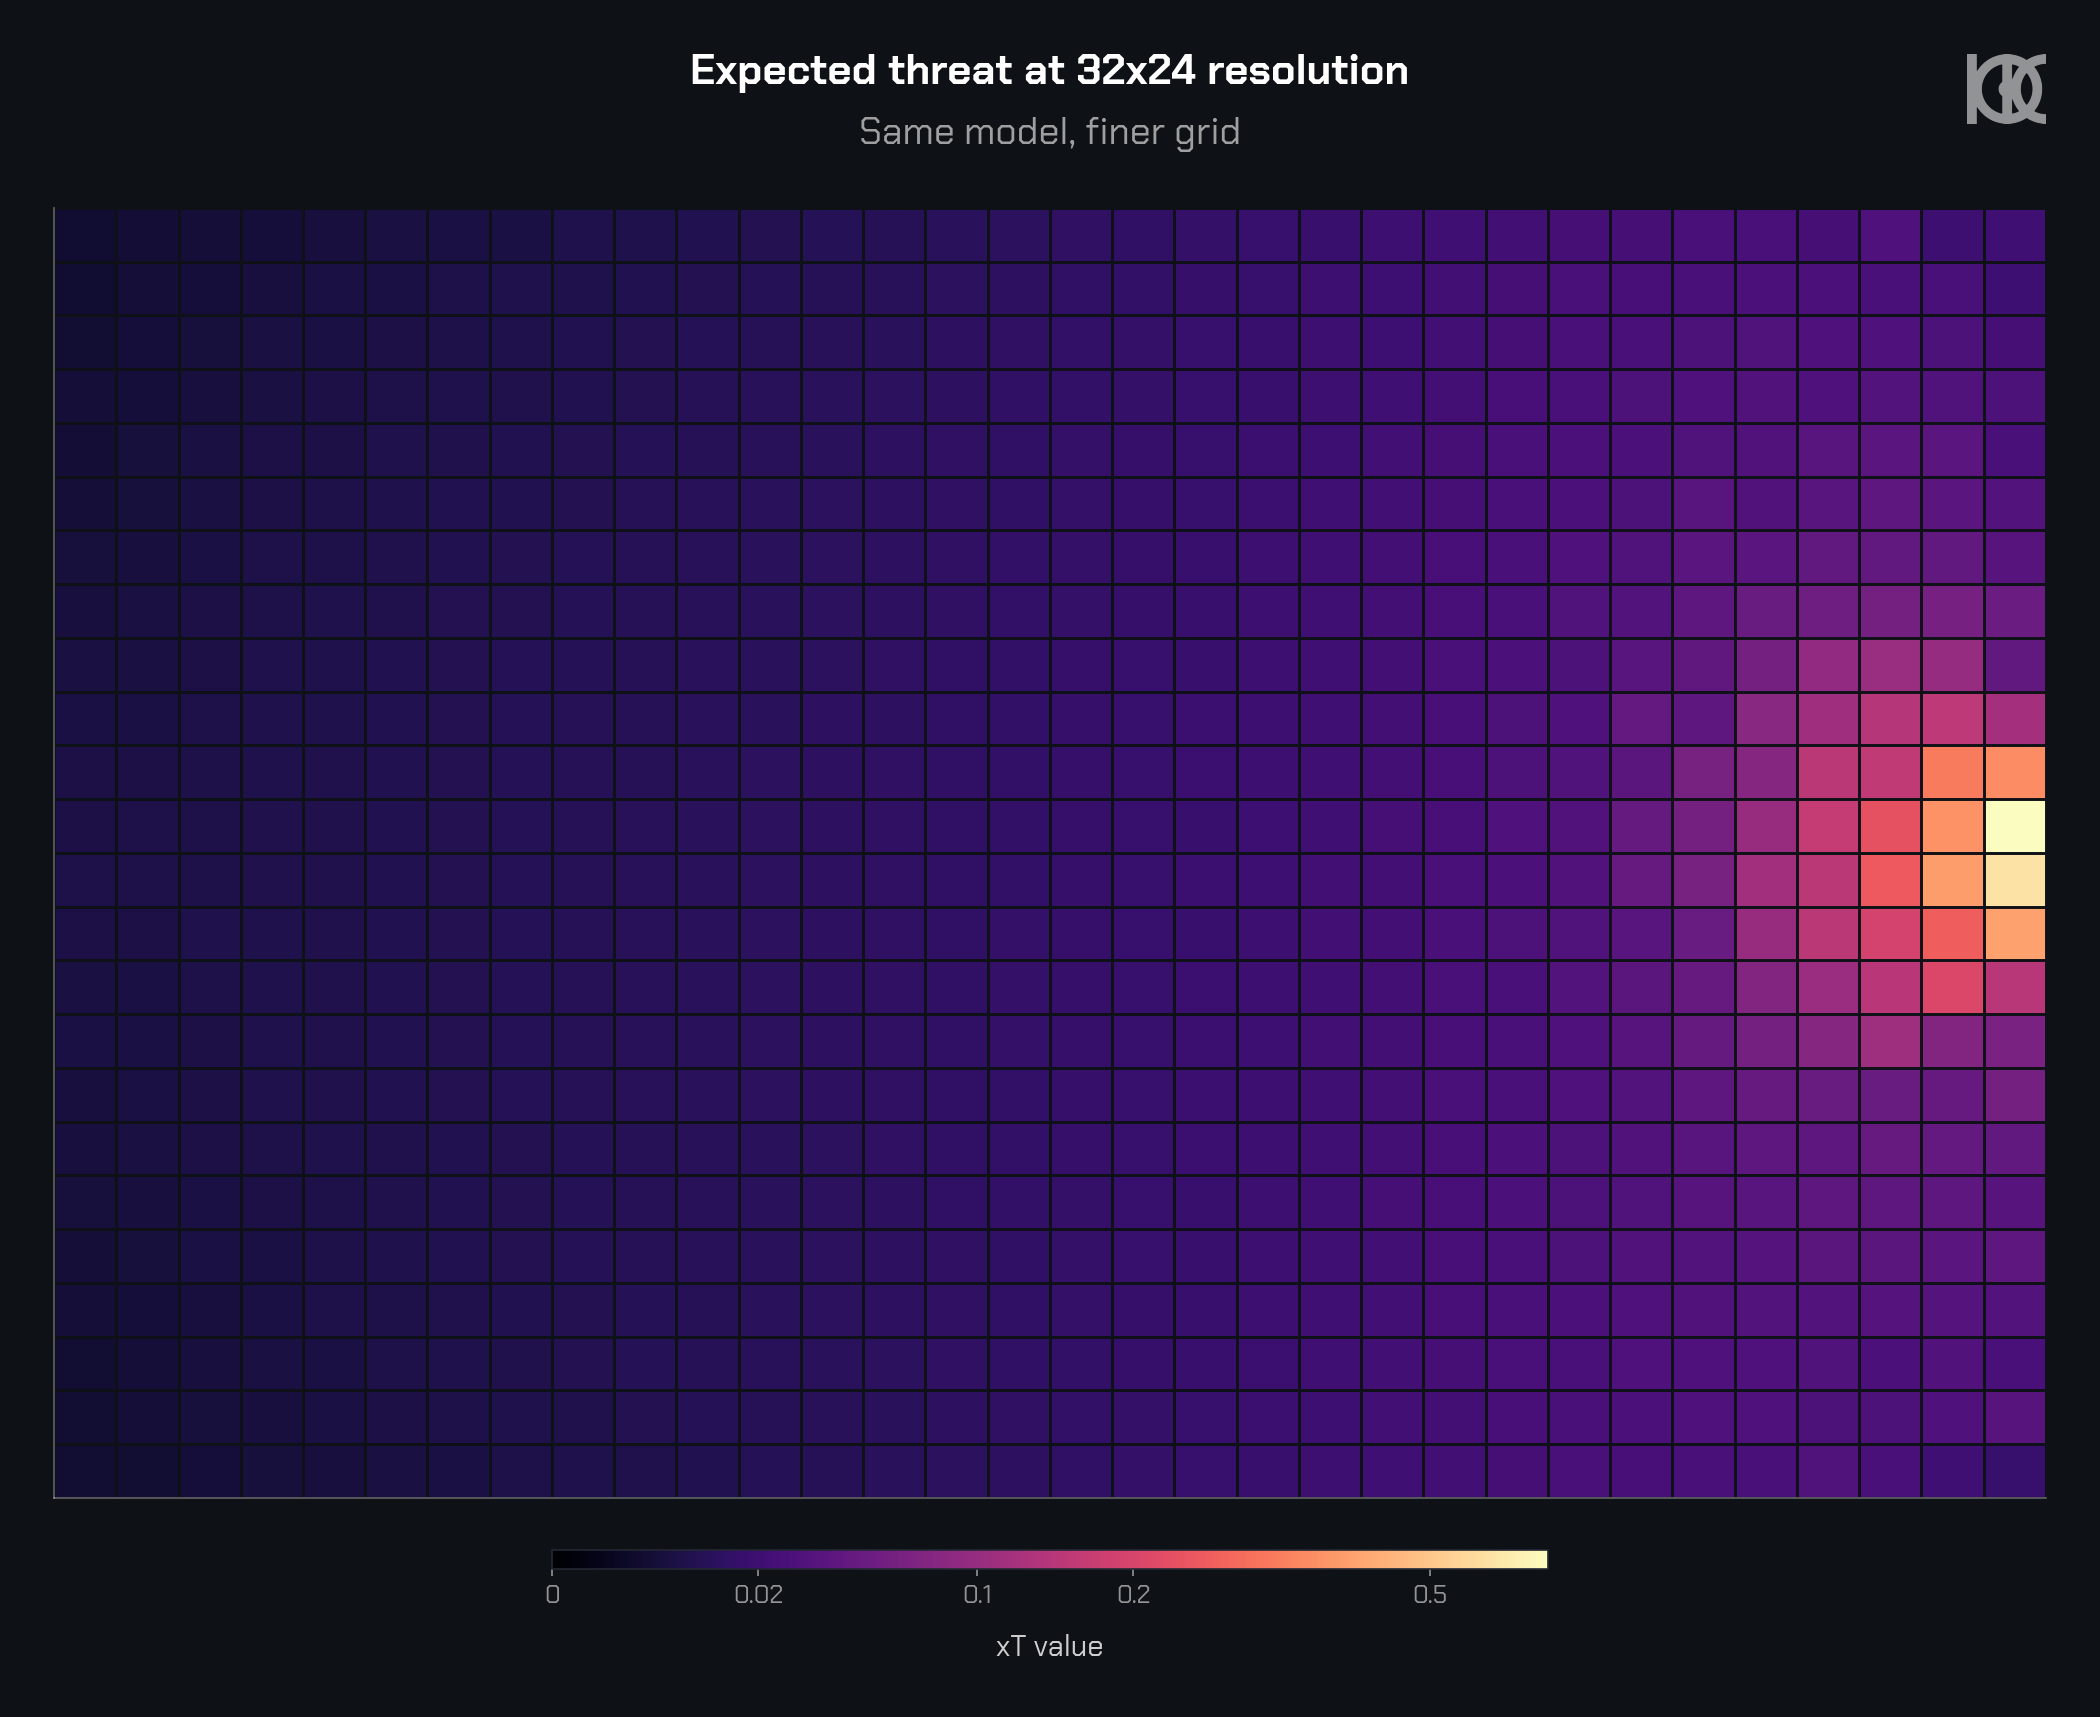

In [22]:
M_FINE = 24   # rows (y-axis)
N_FINE = 32   # cols (x-axis)

print(f"New Grid Resolution: {N_FINE}x{M_FINE} ({N_FINE * M_FINE} states)")

df_actions["start_cell_fine"] = get_flat_indexes(df_actions["start_x"], df_actions["start_y"], l=N_FINE, w=M_FINE)
df_actions["end_cell_fine"] = get_flat_indexes(df_actions["end_x"], df_actions["end_y"], l=N_FINE, w=M_FINE)

# Calculate Probabilities
total_actions_fine = count(df_actions["start_x"], df_actions["start_y"], N_FINE, M_FINE).flatten()
total_actions_fine = np.where(total_actions_fine == 0, 1, total_actions_fine) # avoid div by zero

# Shot and Goal Probabilities
df_shots = df_actions[df_actions["type_name"] == "Shot"]
s_fine = count(df_shots["start_x"], df_shots["start_y"], N_FINE, M_FINE).flatten() / total_actions_fine
g_fine = count(df_shots[df_shots["result"] == 1]["start_x"], df_shots[df_shots["result"] == 1]["start_y"], N_FINE, M_FINE).flatten()
g_fine = g_fine / np.where(count(df_shots["start_x"], df_shots["start_y"], N_FINE, M_FINE).flatten() == 0, 1, count(df_shots["start_x"], df_shots["start_y"], N_FINE, M_FINE).flatten())

# Move Probabilities
df_moves_fine = df_actions[df_actions["type_name"].isin(["Pass", "Carry", "Dribble"])]
m_fine = count(df_moves_fine["start_x"], df_moves_fine["start_y"], N_FINE, M_FINE).flatten() / total_actions_fine

# Transition Matrix
bin_count_fine = N_FINE * M_FINE
T_fine = np.zeros((bin_count_fine, bin_count_fine))
success_moves_fine = df_moves_fine[df_moves_fine["result"] == 1]
counts_fine = success_moves_fine.groupby(["start_cell_fine", "end_cell_fine"]).size().reset_index(name='count')

for _, row in counts_fine.iterrows():
    T_fine[int(row["start_cell_fine"]), int(row["end_cell_fine"])] = row["count"]

# Normalize by ALL attempted moves from each start cell (same as the main
# model): failed moves contribute no mass, so rows sum to <= 1 and the
# shortfall acts as a turnover penalty.
attempts_fine = np.bincount(df_moves_fine["start_cell_fine"], minlength=bin_count_fine).astype(float)
T_fine = T_fine / np.where(attempts_fine == 0, 1, attempts_fine)[:, None]

# Solve xT (same eps / max_iters as the main solver)
xT_fine = np.zeros(bin_count_fine)
diff_fine = 1.0
iters_fine = 0
while diff_fine > eps and iters_fine < max_iters:
    new_xT_fine = (s_fine * g_fine) + (m_fine * (T_fine @ xT_fine))
    diff_fine = np.max(np.abs(new_xT_fine - xT_fine))
    xT_fine = new_xT_fine
    iters_fine += 1

if diff_fine > eps:
    print(f"Warning: fine-grid xT did not converge after {max_iters} iterations (residual {diff_fine:.2e}).")
else:
    print(f"Fine-grid xT converged after {iters_fine} iterations.")

plot_pitch_grid(xT_fine.reshape((M_FINE, N_FINE)), "Expected threat at 32x24 resolution", "xT value",
                subtitle="Same model, finer grid", fmt=".3f")

### BONUS 2: xT with Separated Move Types

In [23]:
N, M = 16, 12  # Original grid size
df_actions["start_cell"] = get_flat_indexes(df_actions["start_x"], df_actions["start_y"], l=N, w=M)
df_actions["end_cell"] = get_flat_indexes(df_actions["end_x"], df_actions["end_y"], l=N, w=M)

total_acts = count(df_actions["start_x"], df_actions["start_y"], N, M).flatten().astype(float)
total_acts[total_acts == 0] = 1.0

In [24]:
def get_move_components(type_names):
    """Calculates probability and transition matrix for a specific set of move types."""
    subset = df_actions[df_actions["type_name"].isin(type_names)]
    p_move = count(subset["start_x"], subset["start_y"], N, M).flatten() / total_acts
    
    success = subset[subset["result"] == 1]
    T = np.zeros((N*M, N*M))
    # Efficiently map counts to matrix using index arrays
    c = success.groupby(["start_cell", "end_cell"]).size().reset_index(name='count')
    T[c["start_cell"].astype(int), c["end_cell"].astype(int)] = c["count"]
    
    # Normalize by ALL attempts of these move types from each start cell
    # (same as the main model), so failed moves act as a turnover penalty.
    attempts = np.bincount(subset["start_cell"], minlength=N * M).astype(float)[:, None]
    return p_move, np.divide(T, attempts, out=np.zeros_like(T), where=attempts != 0)

In [25]:
# Calculate Probabilities & Matrices
p_pass, T_pass = get_move_components(["Pass"])
p_prog, T_prog = get_move_components(["Carry", "Dribble"])

# Shot/Goal Probability
df_shot = df_actions[df_actions["type_name"] == "Shot"]
p_shot = count(df_shot["start_x"], df_shot["start_y"], N, M).flatten() / total_acts
shot_counts = count(df_shot["start_x"], df_shot["start_y"], N, M).flatten()
p_goal_if_shot = count(df_shot[df_shot["result"] == 1]["start_x"], df_shot[df_shot["result"] == 1]["start_y"], N, M).flatten().astype(float)
p_goal_if_shot = np.divide(p_goal_if_shot, shot_counts, out=np.zeros_like(p_goal_if_shot), where=shot_counts != 0)

# Solve xT using the Separated Bellman Equation
shot_threat = p_shot * p_goal_if_shot
xT_sep = np.zeros(N * M)
diff_sep = 1.0
iters_sep = 0
while diff_sep > eps and iters_sep < max_iters:
    new_xT_sep = shot_threat + (p_pass * (T_pass @ xT_sep)) + (p_prog * (T_prog @ xT_sep))
    diff_sep = np.max(np.abs(new_xT_sep - xT_sep))
    xT_sep = new_xT_sep
    iters_sep += 1

if diff_sep > eps:
    print(f"Warning: separated xT did not converge after {max_iters} iterations (residual {diff_sep:.2e}).")
else:
    print(f"Separated xT converged after {iters_sep} iterations.")

# Extract and Plot Contribution Components
pass_grid = (p_pass * (T_pass @ xT_sep)).reshape((M, N))
prog_grid = (p_prog * (T_prog @ xT_sep)).reshape((M, N))

Separated xT converged after 47 iterations.


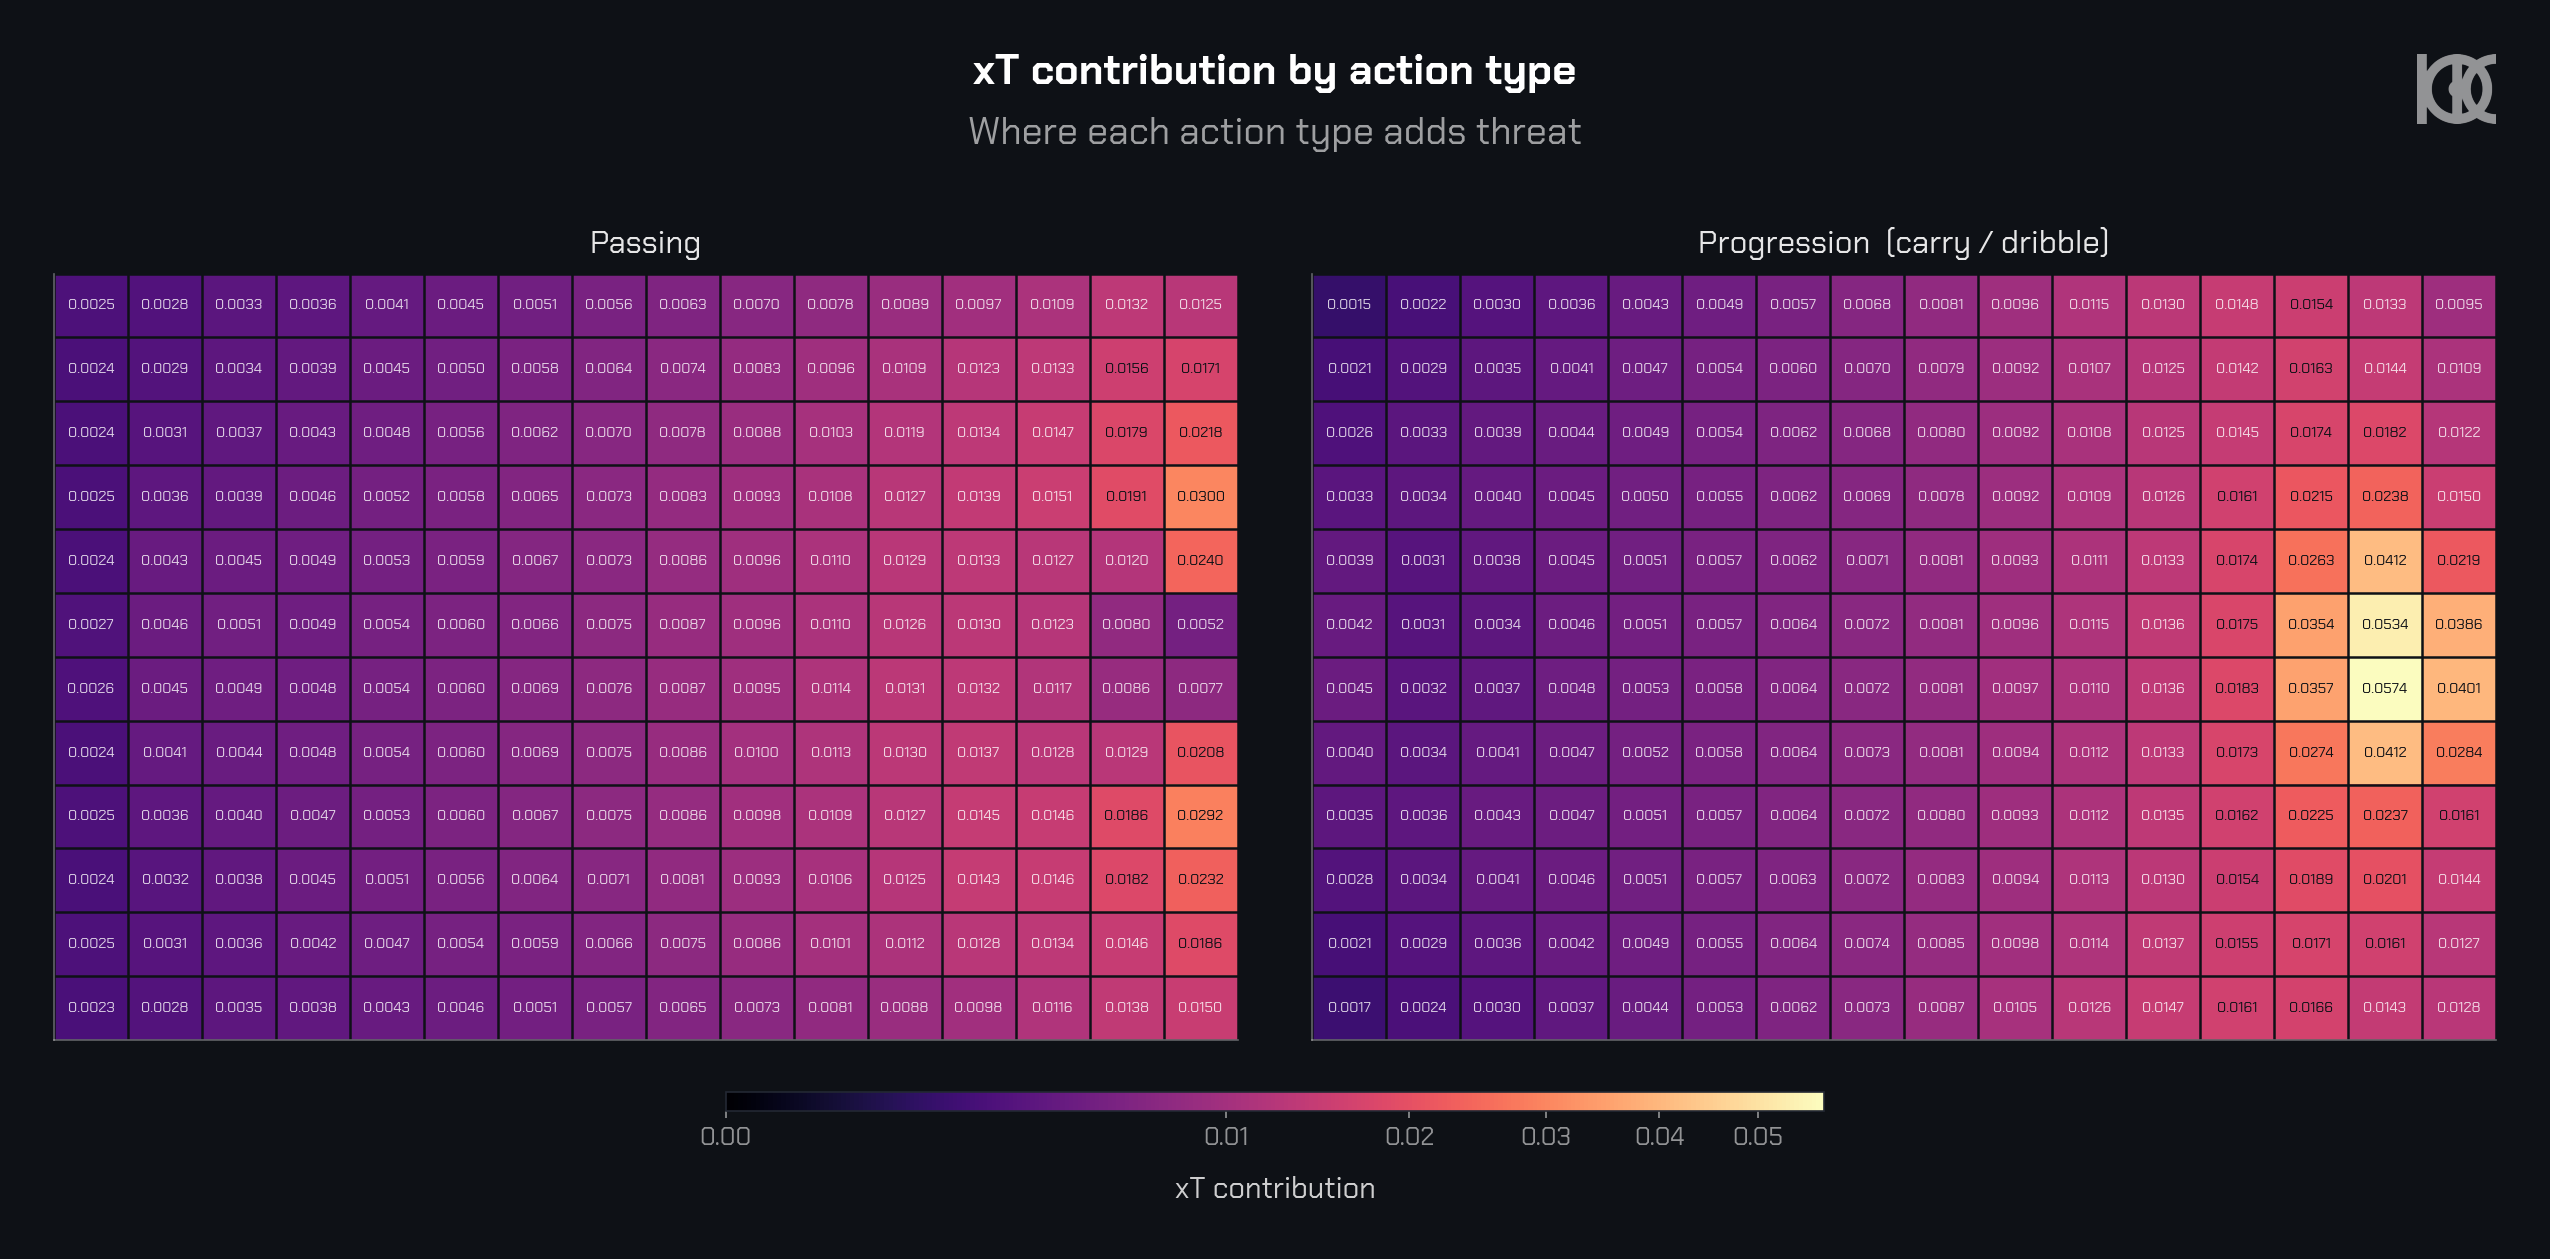

In [26]:
m = KICK_MARGIN_IN; Wf = 17.0; gap = 0.5
pw = (Wf - 2 * m - gap) / 2
ph = pw * 68.0 / 105.0                                  # each panel = pitch 105 x 68
header_band = (20 + 10 + 18) / 72.0 + 2 * m
plabel = 0.44
cbar_band = 2 * m + 0.74
Hf = header_band + plabel + ph + cbar_band
fig = plt.figure(figsize=(Wf, Hf), facecolor=KICK["figure"])
vmax = max(pass_grid.max(), prog_grid.max())
from matplotlib.colors import PowerNorm
norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)
axes_list, im = [], None
for k, (grid, ptitle) in enumerate([(pass_grid, "Passing"),
                                    (prog_grid, "Progression  (carry / dribble)")]):
    w, l = grid.shape
    px = m + k * (pw + gap)
    ax = fig.add_axes([px / Wf, cbar_band / Hf, pw / Wf, ph / Hf]); ax.set_facecolor(KICK["figure"])
    im = ax.imshow(grid, cmap="magma", origin="lower", extent=[0, l, 0, w], aspect="auto", norm=norm)
    ax.set_xlim(0, l); ax.set_ylim(0, w)
    ax.set_xticks(np.arange(0, l + 1), minor=True); ax.set_yticks(np.arange(0, w + 1), minor=True)
    ax.grid(which="minor", color=KICK["figure"], linewidth=1.2); ax.tick_params(which="minor", length=0)
    ax.set_xticks([]); ax.set_yticks([])
    for i in range(w):
        for j in range(l):
            v = grid[i, j]
            ax.text(j + 0.5, i + 0.5, f"{v:.4f}", ha="center", va="center", fontsize=7,
                    color=KICK["figure"] if norm(v) > 0.55 else W(0.80))
    ax._kick_bounds = (0, l, 0, w)
    ax.set_title(ptitle, pad=10, fontsize=15, color=W(0.90))
    axes_list.append(ax)
cw = (2 * pw + gap) * 0.45
cax = fig.add_axes([(Wf - cw) / 2 / Wf, (m + 0.30) / Hf, cw / Wf, 0.13 / Hf])
cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.set_label("xT contribution", color=W(0.80), fontsize=14); cb.ax.xaxis.labelpad = 12
cb.ax.tick_params(colors=W(0.55), labelsize=12); cb.outline.set_edgecolor(KICK["grid"])
fig.canvas.draw()                                       # drop the bar so the LABEL's lowest ink,
lb = cb.ax.xaxis.label.get_window_extent().transformed(fig.transFigure.inverted()).y0
p = cax.get_position()                                  # not the bar, lands on the golden margin
cax.set_position([p.x0, p.y0 + (m / Hf - lb), p.width, p.height])
kick_grid_title(fig, np.array(axes_list).reshape(1, 2), "xT contribution by action type",
                "Where each action type adds threat")
plt.show()